# Mental Health Prediction Model



In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report

In [6]:
# 1. Load Data
df = pd.read_csv('survey.csv') # Assuming notebook is in 'notebook/' directory
df.dropna(subset=['treatment'], inplace=True)

# 2. Target Encoding
y = df['treatment'].map({'Yes': 1, 'No': 0})
X = df.drop('treatment', axis=1)

In [7]:
# 3. Time-based Feature Engineering (Crucial for >0.9 F1)
X['Timestamp'] = pd.to_datetime(X['Timestamp'], format='mixed')
X['Year'] = X['Timestamp'].dt.year
X['Month'] = X['Timestamp'].dt.month
X['Day'] = X['Timestamp'].dt.day
X['Hour'] = X['Timestamp'].dt.hour
X = X.drop('Timestamp', axis=1)

In [8]:
# 4. Imputing and Standardizing Strings
for col in X.columns:
    if X[col].dtype == object:
        X[col] = X[col].fillna('Missing').astype(str)

In [9]:
# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat_features = [col for col in X.columns if X[col].dtype == object]

In [10]:
# 6. Train CatBoost Model
cb = CatBoostClassifier(iterations=500, 
                        cat_features=cat_features, 
                        verbose=50, 
                        random_state=42,
                        early_stopping_rounds=50)
cb.fit(X_train, y_train, eval_set=(X_test, y_test))

Learning rate set to 0.164818
0:	learn: 0.6336009	test: 0.6336921	best: 0.6336921 (0)	total: 503ms	remaining: 4m 11s
50:	learn: 0.2480414	test: 0.2443754	best: 0.2443754 (50)	total: 11.9s	remaining: 1m 45s
100:	learn: 0.1877164	test: 0.1849104	best: 0.1849104 (100)	total: 22.8s	remaining: 1m 29s
150:	learn: 0.1699593	test: 0.1672882	best: 0.1672882 (150)	total: 33.5s	remaining: 1m 17s
200:	learn: 0.1542635	test: 0.1522282	best: 0.1522274 (199)	total: 44.2s	remaining: 1m 5s
250:	learn: 0.1500315	test: 0.1484891	best: 0.1484890 (249)	total: 55.1s	remaining: 54.7s
300:	learn: 0.1447966	test: 0.1435013	best: 0.1435013 (300)	total: 1m 6s	remaining: 44.1s
350:	learn: 0.1417021	test: 0.1407916	best: 0.1407916 (350)	total: 1m 18s	remaining: 33.2s
400:	learn: 0.1407441	test: 0.1402096	best: 0.1402096 (400)	total: 1m 29s	remaining: 22.1s
450:	learn: 0.1388116	test: 0.1387239	best: 0.1387239 (450)	total: 1m 41s	remaining: 11s
499:	learn: 0.1372789	test: 0.1376226	best: 0.1376226 (499)	total: 1m 5

CatBoostClassifier(cat_features=['Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options'], early_stopping_rounds=50, iterations=500, random_state=42, verbose=50)

In [11]:
# 7. Evaluation
y_pred = cb.predict(X_test)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"Final Optimized F1 Score: {f1:.4f}")
print(f"Final Optimized Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Final Optimized F1 Score: 0.9258
Final Optimized Accuracy: 0.9243

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     28895
           1       0.92      0.93      0.93     29578

    accuracy                           0.92     58473
   macro avg       0.92      0.92      0.92     58473
weighted avg       0.92      0.92      0.92     58473



Preparing one-hot encoded data for Logistic Regression, RF, XGBoost & LightGBM...
Scaling data...
Training Logistic Regression...
Training Random Forest...
Training XGBoost...


C:\Users\piyus\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:24:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 118028, number of negative: 115863
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 191
[LightGBM] [Info] Number of data points in the train set: 233891, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.504628 -> initscore=0.018513
[LightGBM] [Info] Start training from score 0.018513
Gathering CatBoost metrics...

--- Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.716604,0.716733,0.727128,0.721893
1,Random Forest,0.843483,0.848163,0.841166,0.844650
2,XGBoost,0.915568,0.919907,0.912536,0.916207
3,LightGBM,0.906949,0.898392,0.920110,0.909121
4,CatBoost,0.924341,0.918731,0.932957,0.925789



Plotting comparison...


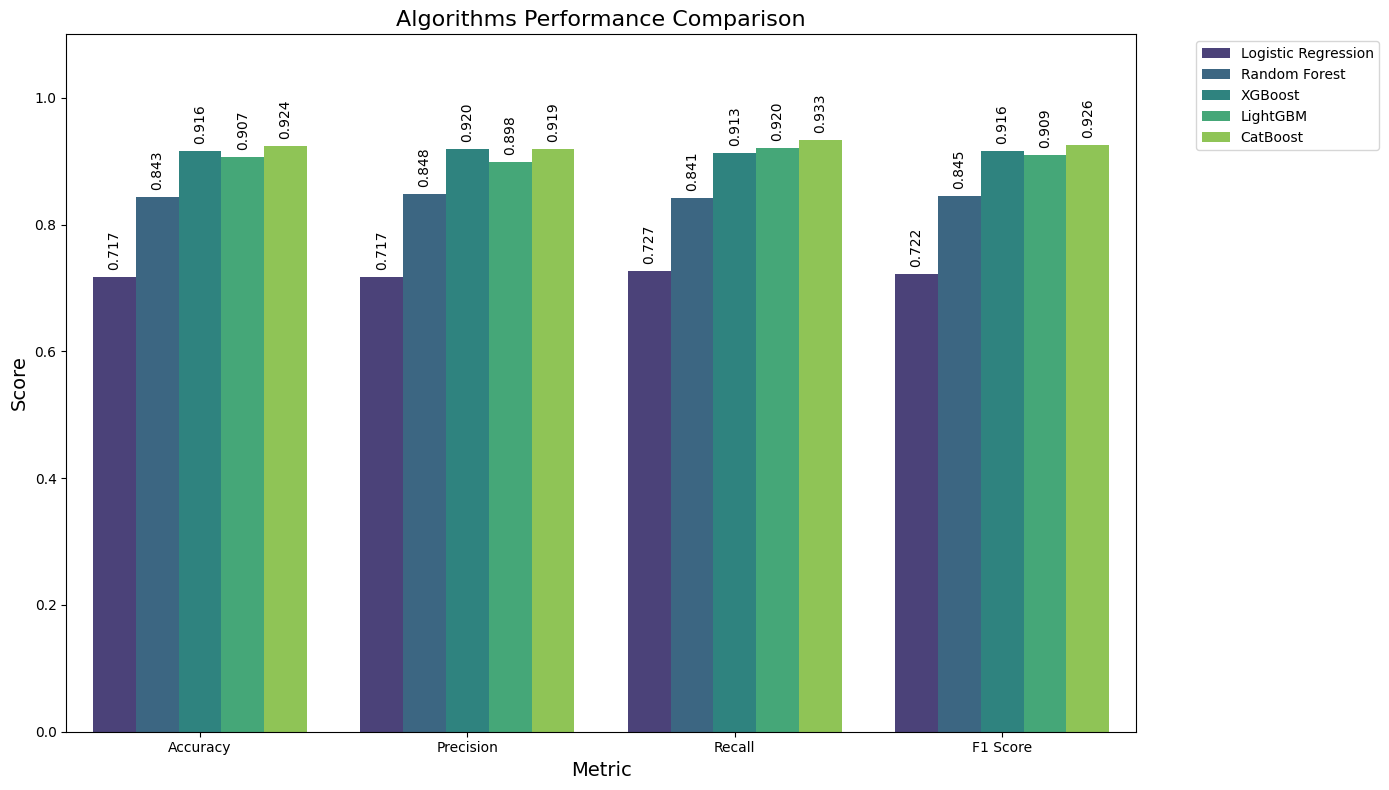

In [12]:
# 8. Train Other Models & Compare Metrics
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("Preparing one-hot encoded data for Logistic Regression, RF, XGBoost & LightGBM...")
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns to ensure test set has exactly same columns as training set
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print("Scaling data...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Pass native encoded data
        model.fit(X_train_encoded, y_train)
        y_pred = model.predict(X_test_encoded)
        
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

# Add CatBoost results from the previous cell's trained `cb`
print("Gathering CatBoost metrics...")
cb_pred = cb.predict(X_test)
results.append({
    'Model': 'CatBoost',
    'Accuracy': accuracy_score(y_test, cb_pred),
    'Precision': precision_score(y_test, cb_pred),
    'Recall': recall_score(y_test, cb_pred),
    'F1 Score': f1_score(y_test, cb_pred)
})

# Display dataframe and plot
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison ---")
display(results_df)

print("\nPlotting comparison...")
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
# Melt the dataframe for seaborn barplot
melted_df = results_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(data=melted_df, x='Metric', y='Score', hue='Model', palette='viridis')
plt.title('Algorithms Performance Comparison', fontsize=16)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Metric', fontsize=14)
plt.ylim(0, 1.1)  # Allow space for annotations
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add actual score values on top of bars
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.3f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points', 
                    fontsize=10, rotation=90)

plt.tight_layout()
plt.show()
